<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.9429 acc 0.659 | val loss 0.5074 acc 0.794 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.7142 acc 0.749 | val loss 0.5689 acc 0.765


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[ConvNeXt-Tiny] Epoch  12/100 | LR: 6.78e-05 | train loss 0.2738 acc 0.918 | val loss 0.6584 acc 0.735


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[ConvNeXt-Tiny] Epoch  13/100 | LR: 6.78e-05 | train loss 0.1981 acc 0.931 | val loss 0.5762 acc 0.824


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[ConvNeXt-Tiny] Epoch  14/100 | LR: 6.78e-05 | train loss 0.1557 acc 0.945 | val loss 0.5928 acc 0.812

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 14.

[ConvNeXt-Tiny] Restored be

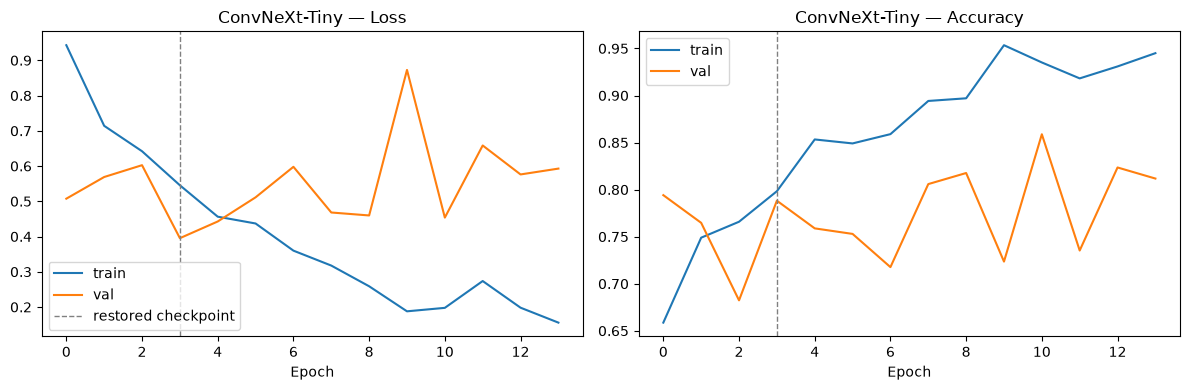

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[ConvNeXt-Tiny] Test accuracy: 0.728


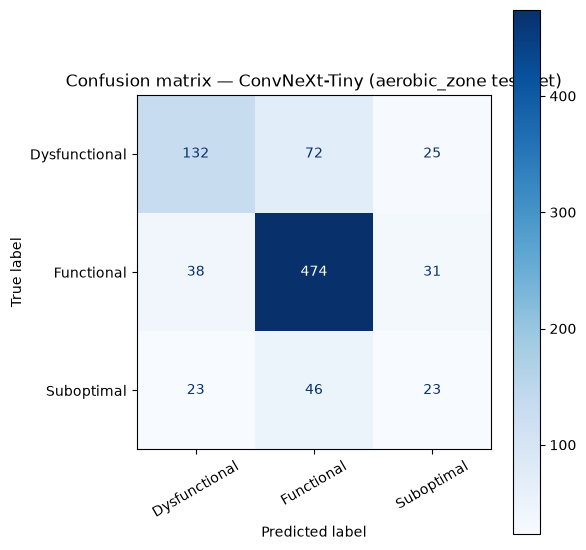

               precision    recall  f1-score   support

Dysfunctional      0.684     0.576     0.626       229
   Functional      0.801     0.873     0.835       543
   Suboptimal      0.291     0.250     0.269        92

     accuracy                          0.728       864
    macro avg      0.592     0.566     0.577       864
 weighted avg      0.715     0.728     0.719       864



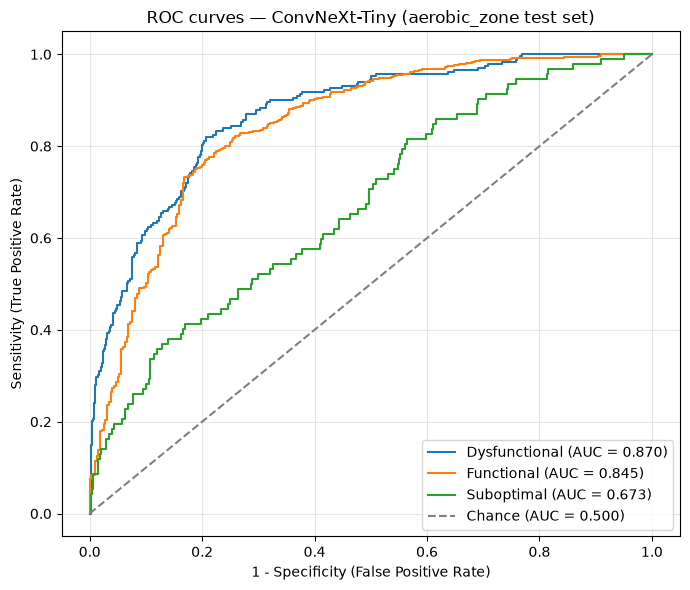

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.870
  Functional     : 0.845
  Suboptimal     : 0.673

Mean AUC (over 3/3 classes with test examples): 0.796


(np.float64(0.7280092592592593),
 {'Dysfunctional': 0.8696695664133686,
  'Functional': 0.8454071358496411,
  'Suboptimal': 0.6731949763460239})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_pad_aug/results_aerobic_zone_convnext_tiny_Waterval.pkl
Saved model weights to ../models/pad/aerobic_zone_convnext_tiny_cnn.pt
